In [5]:
import pandas as pd

# 파이썬이 데이터를 까먹었을 테니 다시 불러와 줍니다!
df_2021 = pd.read_csv('final_crisis_index_by_dong_2021.csv')

# CDI_grade가 없다면 CDI_top30_flag로 대체하여 추출합니다.
columns_cdi = ['자치구명', '행정동명', 'CDI', 'CDI_top30_flag', 'CCI', 'CCI_rank', 'risk_type']
top_10_cdi = df_2021.nlargest(10, 'CDI')[columns_cdi]

print("--- CDI 상위 10개 행정동 ---")
display(top_10_cdi)

# CDI_grade가 없다면 CDI_top30_flag로 대체하여 추출합니다.
columns_cdi = ['자치구명', '행정동명', 'CDI', 'CDI_top30_flag', 'CCI', 'CCI_rank', 'risk_type']
top_10_cdi = df_2021.nlargest(10, 'CDI')[columns_cdi]

print("--- CDI 상위 10개 행정동 ---")
display(top_10_cdi)

# 상위 10개 중 실제 복합위기 최고위험지역(triple_high_flag == 1)에 포함되는 행정동 확인
triple_high_dongs = df_2021[df_2021['triple_high_flag'] == 1]
top_10_cdi_in_triple = top_10_cdi[top_10_cdi['행정동명'].isin(triple_high_dongs['행정동명'])]

print("\n--- CDI 상위 10개 중 복합위기 최고위험지역 포함 행정동 ---")
display(top_10_cdi_in_triple)

--- CDI 상위 10개 행정동 ---


,자치구명,행정동명,CDI,CDI_top30_flag,CCI,CCI_rank,risk_type
12,종로구,창신3동,1.000000,1,0.519608,211,인프라 단일취약형
368,강남구,개포1동,0.998679,1,0.599830,43,사회고립+인프라취약형
39,용산구,이촌2동,0.994716,1,0.546127,144,사회고립+인프라취약형
4,종로구,무악동,0.990753,1,0.503089,260,인프라 단일취약형
53,성동구,응봉동,0.990753,1,0.532781,173,인프라 단일취약형
171,노원구,상계10동,0.990753,1,0.584336,63,인프라+수해취약형
344,서초구,반포본동,0.990753,1,0.449036,378,인프라 단일취약형
42,용산구,서빙고동,0.989432,1,0.613011,33,인프라+수해취약형
281,금천구,시흥2동,0.988111,1,0.519417,212,인프라 단일취약형
401,송파구,잠실7동,0.988111,1,0.516945,220,인프라 단일취약형


--- CDI 상위 10개 행정동 ---


,자치구명,행정동명,CDI,CDI_top30_flag,CCI,CCI_rank,risk_type
12,종로구,창신3동,1.000000,1,0.519608,211,인프라 단일취약형
368,강남구,개포1동,0.998679,1,0.599830,43,사회고립+인프라취약형
39,용산구,이촌2동,0.994716,1,0.546127,144,사회고립+인프라취약형
4,종로구,무악동,0.990753,1,0.503089,260,인프라 단일취약형
53,성동구,응봉동,0.990753,1,0.532781,173,인프라 단일취약형
171,노원구,상계10동,0.990753,1,0.584336,63,인프라+수해취약형
344,서초구,반포본동,0.990753,1,0.449036,378,인프라 단일취약형
42,용산구,서빙고동,0.989432,1,0.613011,33,인프라+수해취약형
281,금천구,시흥2동,0.988111,1,0.519417,212,인프라 단일취약형
401,송파구,잠실7동,0.988111,1,0.516945,220,인프라 단일취약형



--- CDI 상위 10개 중 복합위기 최고위험지역 포함 행정동 ---


,자치구명,행정동명,CDI,CDI_top30_flag,CCI,CCI_rank,risk_type


In [6]:
# CDI는 높지만(상위 30%) IVI나 RII가 낮아서 복합위기 최고위험지역에 포함되지 않은 사례 추출
high_cdi_low_cci = df_2021[(df_2021['CDI_top30_flag'] == 1) & (df_2021['triple_high_flag'] == 0)]

print("--- CDI는 높지만 복합위기 최고위험지역이 아닌 예시 ---")
display(high_cdi_low_cci[['자치구명', '행정동명', 'CDI', 'IVI', 'RII', 'CCI', 'risk_type']])

--- CDI는 높지만 복합위기 최고위험지역이 아닌 예시 ---


,자치구명,행정동명,CDI,IVI,RII,CCI,risk_type
1,종로구,삼청동,0.972259,0.558140,0.213744,0.581381,사회고립+인프라취약형
2,종로구,부암동,0.982827,0.408905,0.368506,0.586746,인프라+수해취약형
3,종로구,평창동,0.949802,0.394242,0.312950,0.552331,인프라 단일취약형
4,종로구,무악동,0.990753,0.360325,0.158188,0.503089,인프라 단일취약형
5,종로구,교남동,0.965654,0.373506,0.158188,0.499116,인프라 단일취약형
...,...,...,...,...,...,...,...
405,송파구,위례동,0.927345,0.104020,0.158188,0.396518,인프라 단일취약형
410,강동구,고덕1동,0.961691,0.198331,0.453487,0.537836,인프라+수해취약형
412,강동구,암사2동,0.928666,0.310346,0.359015,0.532676,인프라 단일취약형
413,강동구,암사3동,0.965654,0.247736,0.403634,0.539008,인프라+수해취약형


C:\Users\sunny\AppData\Local\Temp\ipykernel_37464\1252565673.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_cdi, x='행정동명', y='CDI', palette='Oranges_r')


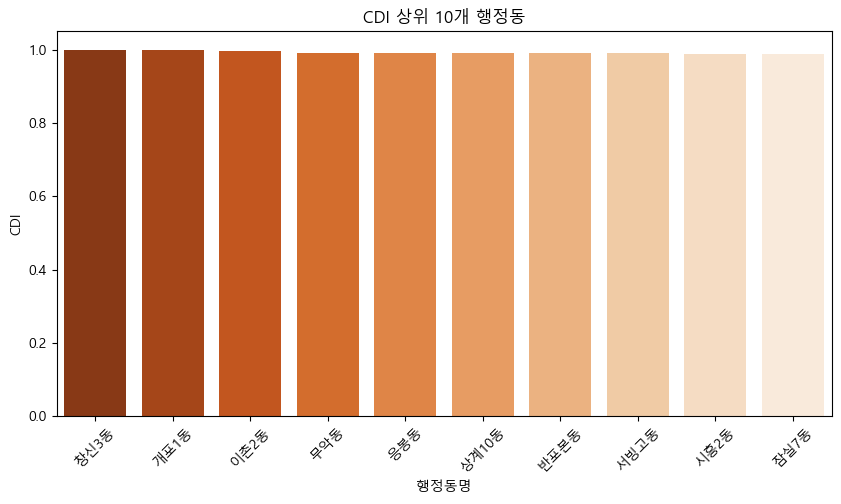

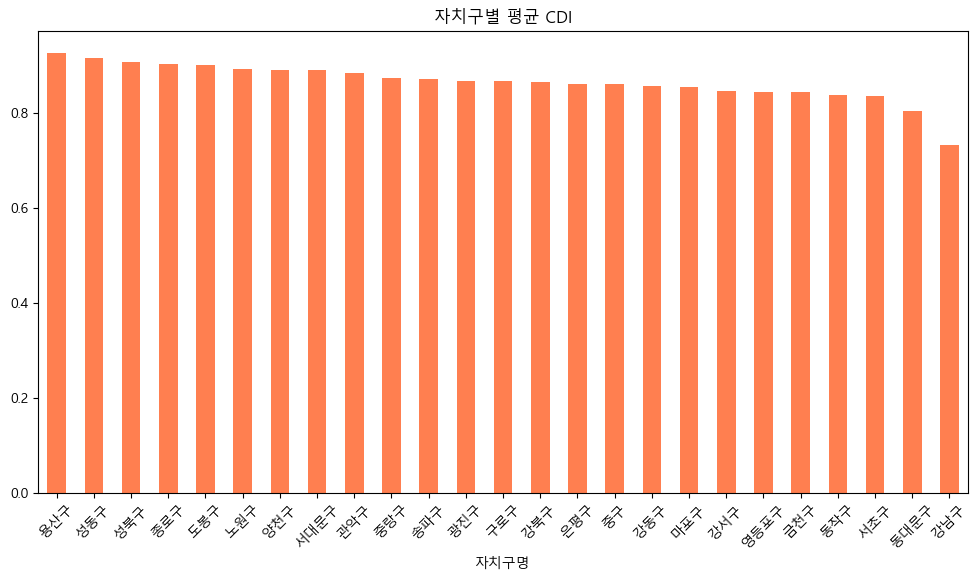

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rc('font', family='Malgun Gothic') # 윈도우 한글 폰트 설정

# 1. CDI 상위 10개 행정동 Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_cdi, x='행정동명', y='CDI', palette='Oranges_r')
plt.title('CDI 상위 10개 행정동')
plt.xticks(rotation=45)
plt.show()

# 2. 자치구별 평균 CDI 막대그래프
gu_mean_cdi = df_2021.groupby('자치구명')['CDI'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
gu_mean_cdi.plot(kind='bar', color='coral')
plt.title('자치구별 평균 CDI')
plt.xticks(rotation=45)
plt.show()
